In [2]:
import tensorflow as tf
print("GPU available:", tf.config.list_physical_devices('GPU'))

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from google.colab import files
files.upload()   # kaggle.json upload karo

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tassaduq14","key":"51afee848c5a0fc4f7ee445698cbb4bf"}'}

In [4]:
import os, shutil
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

In [5]:
!kaggle datasets download -d jangedoo/utkface-new
!unzip -q utkface-new.zip -d /content/utkface

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
100% 331M/331M [00:19<00:00, 17.9MB/s]



In [6]:
import os
files_list = os.listdir('/content/utkface/UTKFace')
print(f"Total images: {len(files_list)}")
print("Sample filenames:", files_list[:5])

Total images: 23708
Sample filenames: ['66_0_0_20170117175358556.jpg.chip.jpg', '1_1_4_20170103204831032.jpg.chip.jpg', '2_1_3_20161219230137680.jpg.chip.jpg', '30_1_0_20170117143843323.jpg.chip.jpg', '21_1_3_20170117142510610.jpg.chip.jpg']


In [7]:
import numpy as np
import pandas as pd
from pathlib import Path

IMG_DIR = Path('/content/utkface/UTKFace')

ages, genders, paths = [], [], []

for img_path in IMG_DIR.glob('*.jpg'):
    parts = img_path.name.split('_')
    if len(parts) < 2:
        continue   # broken filenames skip karo
    try:
        age    = int(parts[0])
        gender = int(parts[1])   # 0 = male, 1 = female
        if 1 <= age <= 100:      # sirf valid ages rakhte hain
            ages.append(age)
            genders.append(gender)
            paths.append(str(img_path))
    except:
        continue

df = pd.DataFrame({'path': paths, 'age': ages, 'gender': genders})
print(f"Total valid images: {len(df)}")
print(df.head())
print(f"\nAge range: {df.age.min()} - {df.age.max()}")
print(f"Gender counts:\n{df.gender.value_counts()}")

Total valid images: 23687
                                                path  age  gender
0  /content/utkface/UTKFace/66_0_0_20170117175358...   66       0
1  /content/utkface/UTKFace/1_1_4_201701032048310...    1       1
2  /content/utkface/UTKFace/2_1_3_201612192301376...    2       1
3  /content/utkface/UTKFace/30_1_0_20170117143843...   30       1
4  /content/utkface/UTKFace/21_1_3_20170117142510...   21       1

Age range: 1 - 100
Gender counts:
gender
0    12386
1    11301
Name: count, dtype: int64


In [8]:
df

,path,age,gender
0,/content/utkface/UTKFace/66_0_0_20170117175358...,66,0
1,/content/utkface/UTKFace/1_1_4_201701032048310...,1,1
2,/content/utkface/UTKFace/2_1_3_201612192301376...,2,1
3,/content/utkface/UTKFace/30_1_0_20170117143843...,30,1
4,/content/utkface/UTKFace/21_1_3_20170117142510...,21,1
...,...,...,...
23682,/content/utkface/UTKFace/79_0_0_20170111222432...,79,0
23683,/content/utkface/UTKFace/85_1_2_20170110182342...,85,1
23684,/content/utkface/UTKFace/58_1_0_20170109142427...,58,1
23685,/content/utkface/UTKFace/39_0_0_20170116222959...,39,0


In [9]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train: {len(train_df)} | Val: {len(val_df)}")

Train: 18949 | Val: 4738


In [10]:
import tensorflow as tf
from tensorflow.keras.utils import Sequence
import cv2

IMG_SIZE = (128, 128)
BATCH    = 32

class FaceDataGenerator(Sequence):
    def __init__(self, dataframe, batch_size=32, augment=False):
        self.df         = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.augment    = augment

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, idx):
        batch = self.df.iloc[idx * self.batch_size:(idx+1) * self.batch_size]
        imgs, ages, genders = [], [], []

        for _, row in batch.iterrows():
            img = cv2.imread(row['path'])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, IMG_SIZE)
            img = img / 255.0   # normalize to [0,1]

            if self.augment:
                # Simple augment: horizontal flip
                if np.random.rand() > 0.5:
                    img = np.fliplr(img)

            imgs.append(img)
            ages.append(row['age'])
            genders.append(row['gender'])

        X = np.array(imgs, dtype=np.float32)
        y = {
            'age_out':    np.array(ages,    dtype=np.float32),
            'gender_out': np.array(genders, dtype=np.float32)
        }
        return X, y

train_gen = FaceDataGenerator(train_df, batch_size=BATCH, augment=True)
val_gen   = FaceDataGenerator(val_df,   batch_size=BATCH, augment=False)
print("Generators ready!")

Generators ready!


In [11]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D)
from tensorflow.keras.applications import MobileNetV2

def build_multi_output_model(img_size=(128, 128, 3)):

    # ── Part A: Backbone (frozen) ──────────────────────────
    base = MobileNetV2(
        input_shape=img_size,
        include_top=False,      # False = last FC layers hataao
        weights='imagenet'      # pre-trained weights use karo
    )
    base.trainable = False      # Phase 1: freeze — sirf head train karo

    # ── Part B: Functional API flow ────────────────────────
    inp = Input(shape=img_size)

    x = base(inp, training=False)        # backbone se features lo
    x = GlobalAveragePooling2D()(x)      # (7,7,1280) → (1280,)
    x = Dense(256, activation='relu')(x) # shared layer
    x = Dropout(0.4)(x)                  # overfitting rokta hai

    # ── Age head (regression) ──────────────────────────────
    age_x   = Dense(128, activation='relu')(x)
    age_out = Dense(1, activation='linear', name='age_out')(age_x)
    # linear activation kyunki age ek number hai (1-100)

    # ── Gender head (binary classification) ────────────────
    gen_x   = Dense(64, activation='relu')(x)
    gen_out = Dense(1, activation='sigmoid', name='gender_out')(gen_x)
    # sigmoid kyunki output 0 ya 1 chahiye (male/female)

    model = Model(inputs=inp, outputs=[age_out, gen_out])
    return model

model = build_multi_output_model()
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_1… │ (None, 4, 4,      │  2,257,984 │ input_layer_1[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    327,936 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     16,448 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_out (Dense)     │ (None, 1)         │        129 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_out (Dense)  │ (None, 1)         │         65 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,635,458 (10.05 MB)

 Trainable params: 377,474 (1.44 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss={
        'age_out':    'mae',                 # Mean Absolute Error
        'gender_out': 'binary_crossentropy'
    },
    loss_weights={
        'age_out':    1.0,   # age loss ka weight
        'gender_out': 10.0   # gender loss thoda zyada — balance ke liye
    },
    metrics={
        'age_out':    'mae',
        'gender_out': 'accuracy'
    }
)
print("Model compiled!")

Model compiled!


In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', patience=2, factor=0.5
    )
]

print("Phase 1: Training head only (backbone frozen)...")
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks
)

Phase 1: Training head only (backbone frozen)...
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


593/593 ━━━━━━━━━━━━━━━━━━━━ 73s 89ms/step - age_out_loss: 10.7103 - age_out_mae: 10.7195 - gender_out_accuracy: 0.7740 - gender_out_loss: 0.4708 - loss: 15.4322 - val_age_out_loss: 9.0931 - val_age_out_mae: 9.1307 - val_gender_out_accuracy: 0.8246 - val_gender_out_loss: 0.3796 - val_loss: 12.9238 - learning_rate: 0.0010
Epoch 2/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step - age_out_loss: 9.3146 - age_out_mae: 9.3208 - gender_out_accuracy: 0.8186 - gender_out_loss: 0.3981 - loss: 13.3059 - val_age_out_loss: 8.4548 - val_age_out_mae: 8.4951 - val_gender_out_accuracy: 0.8301 - val_gender_out_loss: 0.3604 - val_loss: 12.0969 - learning_rate: 0.0010
Epoch 3/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - age_out_loss: 8.9207 - age_out_mae: 8.9247 - gender_out_accuracy: 0.8280 - gender_out_loss: 0.3766 - loss: 12.6956 - val_age_out_loss: 9.3552 - val_age_out_mae: 9.3994 - val_gender_out_accuracy: 0.8343 - val_gender_out_loss: 0.3547 - val_loss: 12.9453 - learning_rate: 0.0010
Epoch 4/15
59

In [17]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, type(layer).__name__)

0 input_layer_1 InputLayer
1 mobilenetv2_1.00_128 Functional
2 global_average_pooling2d GlobalAveragePooling2D
3 dense Dense
4 dropout Dropout
5 dense_1 Dense
6 dense_2 Dense
7 age_out Dense
8 gender_out Dense


In [18]:
# FIXED: [2] ki jagah [1]
base_model = model.layers[1]
print("Using:", base_model.name)  # mobilenetv2_1.00_128 aana chahiye

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss={'age_out': 'mae', 'gender_out': 'binary_crossentropy'},
    loss_weights={'age_out': 1.0, 'gender_out': 10.0},
    metrics={'age_out': 'mae', 'gender_out': 'accuracy'}
)

print("Phase 2: Fine-tuning last 30 layers...")
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)

Using: mobilenetv2_1.00_128
Phase 2: Fine-tuning last 30 layers...
Epoch 1/20
593/593 ━━━━━━━━━━━━━━━━━━━━ 58s 66ms/step - age_out_loss: 10.7139 - age_out_mae: 10.7158 - gender_out_accuracy: 0.7878 - gender_out_loss: 0.4440 - loss: 15.1576 - val_age_out_loss: 9.1003 - val_age_out_mae: 9.1456 - val_gender_out_accuracy: 0.8438 - val_gender_out_loss: 0.3449 - val_loss: 12.5954 - learning_rate: 1.0000e-05
Epoch 2/20
593/593 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - age_out_loss: 9.0440 - age_out_mae: 9.0448 - gender_out_accuracy: 0.8305 - gender_out_loss: 0.3743 - loss: 12.7843 - val_age_out_loss: 8.9603 - val_age_out_mae: 9.0104 - val_gender_out_accuracy: 0.8493 - val_gender_out_loss: 0.3393 - val_loss: 12.4088 - learning_rate: 1.0000e-05
Epoch 3/20
593/593 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - age_out_loss: 8.3169 - age_out_mae: 8.3201 - gender_out_accuracy: 0.8442 - gender_out_loss: 0.3463 - loss: 11.7840 - val_age_out_loss: 8.9547 - val_age_out_mae: 9.0069 - val_gender_out_accuracy: 0.8573 -

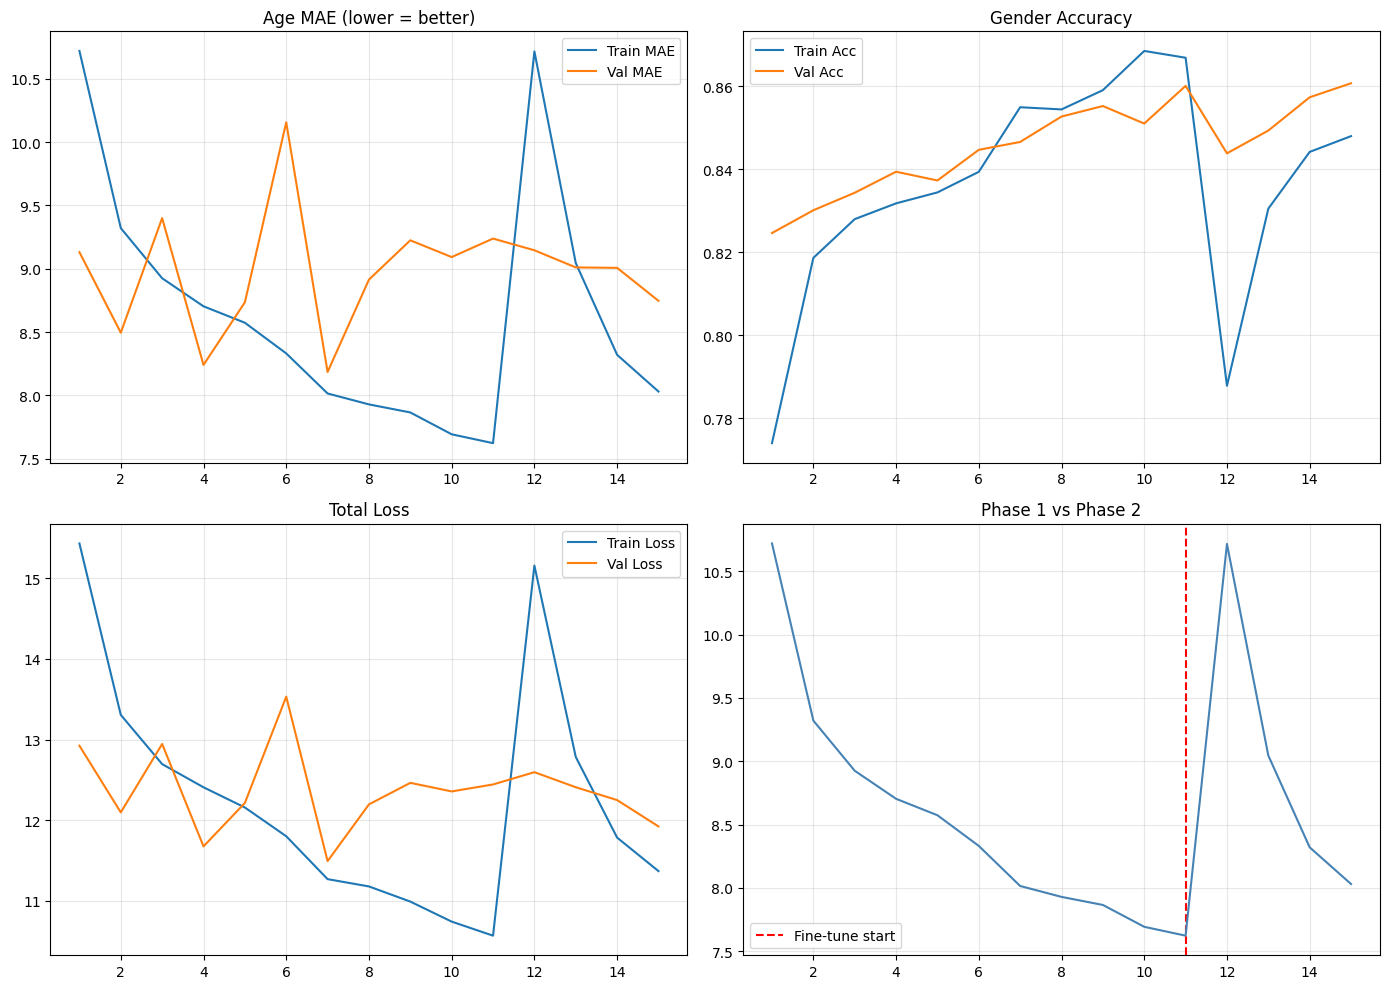

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Combine history
h1 = history1.history
h2 = history2.history

def combine(key):
    return h1.get(key, []) + h2.get(key, [])

epochs_total = range(1, len(combine('loss')) + 1)

axes[0,0].plot(epochs_total, combine('age_out_mae'),     label='Train MAE')
axes[0,0].plot(epochs_total, combine('val_age_out_mae'), label='Val MAE')
axes[0,0].set_title('Age MAE (lower = better)')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(epochs_total, combine('gender_out_accuracy'),     label='Train Acc')
axes[0,1].plot(epochs_total, combine('val_gender_out_accuracy'), label='Val Acc')
axes[0,1].set_title('Gender Accuracy')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(epochs_total, combine('loss'),     label='Train Loss')
axes[1,0].plot(epochs_total, combine('val_loss'), label='Val Loss')
axes[1,0].set_title('Total Loss')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].axvline(x=len(h1['loss']), color='red', linestyle='--', label='Fine-tune start')
axes[1,1].plot(epochs_total, combine('age_out_mae'), color='steelblue')
axes[1,1].set_title('Phase 1 vs Phase 2')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_results.png', dpi=150)
plt.show()

In [20]:
model.save('/content/utkface_model.h5')
print("Model saved!")

# Google Drive pe save karo (optional but recommended)
from google.colab import drive
drive.mount('/content/drive')
import shutil
shutil.copy('/content/utkface_model.h5',
            '/content/drive/MyDrive/utkface_model.h5')
print("Saved to Google Drive too!")

Model saved!
Mounted at /content/drive
Saved to Google Drive too!


Model loaded!
Upload Photo:


Saving fe61dba545c0b8b87a722cad8408d37d.jpg to fe61dba545c0b8b87a722cad8408d37d.jpg

Testing: fe61dba545c0b8b87a722cad8408d37d.jpg


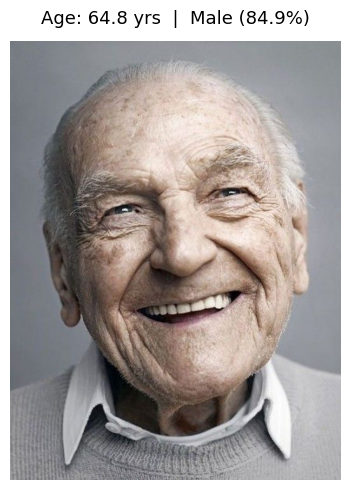

Age    : 64.8 years
Gender : Male (84.9% confident)


In [45]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from google.colab import files
import tensorflow as tf

# FIXED: compile=False
model = load_model('/content/utkface_model.h5', compile=False)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss={'age_out': 'mae', 'gender_out': 'binary_crossentropy'},
    loss_weights={'age_out': 1.0, 'gender_out': 10.0},
    metrics={'age_out': 'mae', 'gender_out': 'accuracy'}
)
print("Model loaded!")

def predict_face(image_path):
    img_bgr = cv2.imread(image_path)

    # FIXED: agar image load na ho
    if img_bgr is None:
        print(f"ERROR: Image load nahi hui — {image_path}")
        return None, None

    img_rgb     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (128, 128))
    img_batch   = np.expand_dims(img_resized / 255.0, axis=0)

    age_pred, gender_pred = model.predict(img_batch, verbose=0)

    age          = float(age_pred[0][0])
    gender_val   = float(gender_pred[0][0])
    gender_label = 'Female' if gender_val > 0.5 else 'Male'
    gender_conf  = gender_val * 100 if gender_val > 0.5 else (1 - gender_val) * 100

    plt.figure(figsize=(5, 5))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(
        f"Age: {age:.1f} yrs  |  {gender_label} ({gender_conf:.1f}%)",
        fontsize=13, pad=12
    )
    plt.tight_layout()
    plt.show()

    print(f"Age    : {age:.1f} years")
    print(f"Gender : {gender_label} ({gender_conf:.1f}% confident)")
    return age, gender_label

# Upload + predict
print("Upload Photo:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nTesting: {filename}")
    predict_face(filename)